# 🧠 Aircraft Damage Classification & Image Captioning with Pretrained Models

**Module:** 02 — Intro to Deep Learning & Neural Networks with Keras  
**Author:** Reda (IsReda)  
**Date:** 2026-05-25  

> In this project I build two AI pipelines for aviation safety:
> 1. A **binary image classifier** that distinguishes aircraft *dents* from *cracks* using VGG16 as a frozen feature extractor.
> 2. An **image captioning system** using BLIP (Bootstrapping Language-Image Pretraining), wrapped inside a custom Keras layer.
>
> **Telecom / RF analogy 📡:** Transfer learning works like antenna beam-forming — I reuse a calibrated reference array (VGG16 trained on ImageNet) and point it at a new problem (aircraft damage), adding only a lightweight beamforming head on top. The bulk of the computation is already done.

## 📋 Overview

| | |
|---|---|
| **Dataset** | Aircraft Damage Dataset v1 — 2 classes: `dent`, `crack` |
| **Part 1 model** | VGG16 (frozen) + custom Dense head — binary classification |
| **Part 2 model** | BLIP (Salesforce) — image captioning & summarization |
| **Framework** | TensorFlow / Keras + PyTorch (for BLIP via Hugging Face) |
| **Key technique** | Transfer learning (feature extraction, frozen weights) |

### 📐 Structure

```
Part 1 — Classification
  1.1  Dataset Preparation
  1.2  Data Preprocessing
  1.3  Model Definition (VGG16 + head)
  1.4  Model Training
  1.5  Visualising Training Results
  1.6  Model Evaluation
  1.7  Visualising Predictions

Part 2 — Image Captioning
  2.1  Loading BLIP Model
  2.2  Generating Captions & Summaries

📊 Summary
🧪 Sandbox
```

## 🧩 Theory — Transfer Learning & Pretrained Models

### What is a pretrained model?

A **pretrained model** is a neural network that has already been trained on a massive dataset (e.g., ImageNet: 1.2 million images, 1 000 classes). Its layers have learned general visual features — edges, textures, shapes — that transfer well to new tasks.

Instead of training from scratch (expensive, requires huge data), I **freeze** the pretrained weights and bolt on a small trainable head for my specific task. This is called **feature extraction**.

### The two modes of transfer learning

| Mode | Pretrained weights | Custom head | When to use |
|---|---|---|---|
| **Feature extraction** | Frozen ❄️ | Trained | Small dataset, similar domain |
| **Fine-tuning** | Partially unfrozen 🔥 | Trained | Larger dataset, different domain |

In this project I use **feature extraction** — VGG16 is frozen, only the Dense head is trained.

### VGG16 architecture

VGG16 is a 16-layer CNN (13 Conv + 3 Dense) from Oxford's VGG group, trained on ImageNet. For feature extraction, I remove the top Dense layers (`include_top=False`) and use the final Conv feature map as input to my own classifier.

$$\text{Input} (224 \times 224 \times 3) \xrightarrow{\text{VGG16 Conv blocks}} \text{Feature map} (7 \times 7 \times 512) \xrightarrow{\text{Flatten}} \mathbf{z} \xrightarrow{\text{Dense head}} \hat{y}$$

### Binary classification loss

For two classes (dent / crack) I use **binary cross-entropy**:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

where $y_i \in \{0, 1\}$ is the true label and $\hat{y}_i = \sigma(z_i) \in (0, 1)$ is the sigmoid output.

The **sigmoid activation** maps any real value to $(0, 1)$:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**RF analogy 📡:** Binary cross-entropy is analogous to the bit-error probability in digital communications — it measures how wrong my probability estimate is for each bit (class label). Minimising it is like maximising the log-likelihood of the correct signal hypothesis under Gaussian noise.

## ⚙️ Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

### 📦 Installing Required Libraries

I install the exact pinned versions to ensure reproducibility across environments.

In [2]:
!pip install pandas==2.2.3
!pip install tensorflow==2.17.0
!pip install pillow==11.1.0
!pip install matplotlib==3.9.2
!pip install transformers==4.38.2
!pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0

  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.2/236.2 MB 9.2 MB/s  0:00:25m0:00:0100:01
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 147.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 102.0 MB/s  0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.1
    Uninstalling protobuf-7.34.1:
      Successfully uninstalled protobuf-7.34.1
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:╸━━━━━━━━━━━━━━━━━━━━━━ 4/9 [numpy]
      Successfully uninstalled numpy-2.4.4━━━━━━━━━━━━━━━━━━━━ 4/9 [numpy]
  Attempting uninstall: ml-dtypes━╸━━━━━━━━━━━━━ 6/9 [tensorboard]
    Found existing installation: ml_dtypes 0.5.4m━━━━━━━━━━━━━ 6/9 [tensorboard]
    Uninstalling ml_dtypes-0.5.4:m╸━━━━━━━━━━━━━ 6/9 [tensorboard]
      Successfull

In [3]:
# Suppress TensorFlow CPU-backend warnings — comment out if running on GPU
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

### 📥 Importing Libraries

In [4]:
import zipfile
import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten
from keras.applications import VGG16
from keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from keras.preprocessing import image
import random

In [5]:
# 🎯 Set seed for full reproducibility across Python, NumPy, and TensorFlow
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

---

## Part 1 — 🏗️ Classification: Dent vs Crack

I build a binary image classifier that takes aircraft photos and predicts whether the visible damage is a **dent** or a **crack**. This is a classic CV problem in predictive maintenance — the same approach applies to defect detection on RF antenna arrays, microwave waveguides, or PCB inspection in telecom hardware.

### 1.1 📁 Dataset Preparation

The dataset is pre-split into `train/`, `valid/`, and `test/` folders, each containing `dent/` and `crack/` subfolders. This is the standard Keras `flow_from_directory` layout.

**Configuration:** I fix `batch_size = 32` and `n_epochs = 5`. The image size `224 × 224` is dictated by VGG16's expected input shape.

| Parameter | Value | Why |
|---|---|---|
| `batch_size` | 32 | Standard default — balances gradient noise and memory |
| `n_epochs` | 5 | Enough for a frozen-weight head to converge on a small dataset |
| `img_rows/cols` | 224 | VGG16 was trained on 224×224 — must match |
| `input_shape` | (224, 224, 3) | Height × Width × RGB channels |

In [6]:
# 🔢 Model configuration
batch_size = 32
n_epochs = 5
img_rows, img_cols = 224, 224
input_shape = (img_rows, img_cols, 3)

I download the dataset as a `.tar` archive and extract it. The `shutil.rmtree` guard prevents duplicate data if the cell is re-run.

In [7]:
import tarfile
import urllib.request
import os
import shutil

# URL of the tar file
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ZjXM4RKxlBK9__ZjHBLl5A/aircraft-damage-dataset-v1.tar"

tar_filename = "aircraft_damage_dataset_v1.tar"
extracted_folder = "aircraft_damage_dataset_v1"

# Download
urllib.request.urlretrieve(url, tar_filename)
print(f"Downloaded {tar_filename}. Extraction will begin now.")

# Remove existing folder to avoid stale data
if os.path.exists(extracted_folder):
    print(f"Removing existing folder: {extracted_folder}")
    shutil.rmtree(extracted_folder)

# Extract
with tarfile.open(tar_filename, "r") as tar_ref:
    tar_ref.extractall()
    print(f"Extracted {tar_filename} successfully.")

Downloaded aircraft_damage_dataset_v1.tar. Extraction will begin now.
Removing existing folder: aircraft_damage_dataset_v1
Extracted aircraft_damage_dataset_v1.tar successfully.


The folder structure after extraction:

```
aircraft_damage_dataset_v1/
├── train/
│   ├── dent/
│   └── crack/
├── valid/
│   ├── dent/
│   └── crack/
└── test/
    ├── dent/
    └── crack/
```

Keras' `flow_from_directory` reads the subfolder names as class labels automatically — no manual label encoding needed.

In [8]:
# Define directory paths
extract_path = "aircraft_damage_dataset_v1"
train_dir = os.path.join(extract_path, 'train')
test_dir  = os.path.join(extract_path, 'test')
valid_dir = os.path.join(extract_path, 'valid')

### 1.2 🔄 Data Preprocessing

I use `ImageDataGenerator` to normalise pixel values from $[0, 255]$ to $[0, 1]$ by dividing by 255. This rescaling is the only preprocessing I apply — VGG16 was trained with this normalisation scheme.

**Why rescale?** Neural networks are sensitive to input scale. Raw pixel values in $[0, 255]$ have large gradients during backprop. Normalising to $[0, 1]$ (or $[-1, 1]$) keeps activations in a stable range, similar to how I'd apply automatic gain control (AGC) on an RF receiver before demodulation.

$$x_{\text{norm}} = \frac{x_{\text{pixel}}}{255}$$

> **Note:** I intentionally omit data augmentation here (flips, rotations, etc.) since the dataset is pre-split and the goal is feature extraction from a frozen base — augmentation would help more during fine-tuning.

In [9]:
# 🔄 Create ImageDataGenerators — rescale pixels to [0, 1]
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

The `flow_from_directory()` method reads images from disk in batches — essential when the dataset is too large for RAM. The `class_mode='binary'` flag tells Keras this is a 2-class problem with a single sigmoid output.

In [10]:
# 📥 Training generator — shuffle=True for stochastic gradient descent
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    seed=seed_value,
    class_mode='binary',
    shuffle=True
)

Found 300 images belonging to 2 classes.


#### ✅ Task 1 — Validation Generator

I create `valid_generator` using `valid_datagen.flow_from_directory()`. I set `shuffle=False` because during validation I want to evaluate images in a consistent, deterministic order — shuffling would make it harder to debug misclassified samples.

In [11]:
# ✅ Task 1 — valid_generator
valid_generator = valid_datagen.flow_from_directory(
    directory=valid_dir,
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    seed=seed_value,
    class_mode='binary',
    shuffle=False
)

Found 96 images belonging to 2 classes.


#### ✅ Task 2 — Test Generator

Same approach for the test set. `shuffle=False` is critical here — when I call `model.evaluate()` and compare predictions to true labels, the label order must match the image order.

In [13]:
# ✅ Task 2 — test_generator
test_generator = test_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    seed=seed_value,
    class_mode='binary',
    shuffle=False
)

Found 50 images belonging to 2 classes.


### 1.3 🏗️ Model Definition

I build a two-stage model:
1. **VGG16 base** — frozen feature extractor (no training)
2. **Custom Dense head** — trained binary classifier

The frozen VGG16 acts as a fixed feature bank. Each image is transformed into a 25 088-dimensional vector ($ 7 \times 7 \times 512 = 25\,088$) that encodes rich visual semantics. My small Dense head then learns to separate dents from cracks within that feature space.

**Telecom analogy 📡:** This is like using a pre-characterised channel equaliser (VGG16) and adding only a custom decision boundary (Dense head) on top. The channel model is fixed; only the detector adapts.

#### ✅ Task 3 — Load VGG16

Key parameters:
- `weights='imagenet'` — load weights pretrained on ImageNet (not random initialisation)
- `include_top=False` — exclude VGG16's original Dense classifier (1 000 ImageNet classes)
- `input_shape=(224, 224, 3)` — fix the expected input dimensions

In [14]:
# ✅ Task 3 — Load VGG16 as frozen feature extractor
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_rows, img_cols, 3))

In [15]:
# Flatten the last Conv output → 1D feature vector, then freeze all base layers
output = base_model.layers[-1].output
output = keras.layers.Flatten()(output)
base_model = Model(base_model.input, output)

# ❄️ Freeze VGG16 — weights will NOT update during training
for layer in base_model.layers:
    layer.trainable = False

print(f"VGG16 base: {len(base_model.layers)} layers frozen")
print(f"Feature vector size: {base_model.output_shape[1]:,}")

VGG16 base: 20 layers frozen
Feature vector size: 25,088


I add two Dense(512) blocks with Dropout(0.3) for regularisation, then a final Dense(1, sigmoid) for binary output.

**Dropout analogy 📡:** Dropout is like randomly switching off antenna elements in an array. The surviving elements must still decode the signal correctly — forcing the network to build redundant, generalised representations rather than relying on specific neurons.

In [16]:
# 🏗️ Build the custom classification head
model = Sequential()
model.add(base_model)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))  # σ(z) → probability of class 1 (crack)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional (Functional)         │ (None, 25088)          │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,823,425 (106.14 MB)

 Trainable params: 13,108,737 (50.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

#### ✅ Task 4 — Compile the Model

I compile with:
- **`Adam(lr=0.0001)`** — adaptive learning rate; starts at $10^{-4}$ to avoid overshooting with the pretrained base
- **`binary_crossentropy`** — the correct loss for sigmoid output with $y \in \{0, 1\}$
- **`accuracy`** — primary metric to track during training

$$\text{Adam update:} \quad \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

where $\hat{m}_t$ and $\hat{v}_t$ are bias-corrected estimates of the first and second moments of the gradient.

In [17]:
# ✅ Task 4 — Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### 1.4 🔄 Model Training

With the base frozen, only the Dense head's weights update. The model sees each training image once per epoch. At 5 epochs the head has had enough passes to converge on the VGG16 feature space.

**What `model.fit()` does:**
1. Pulls a batch of 32 images from `train_generator`
2. Forward pass → compute loss
3. Backprop → compute gradients (only for unfrozen layers)
4. Adam → update Dense head weights
5. Repeat until all training batches are processed → 1 epoch done
6. Evaluate on `valid_generator` → log `val_loss` and `val_accuracy`

#### ✅ Task 5 — Train the Model

In [19]:
# ✅ Task 5 — Train
history = model.fit(
    train_generator,
    epochs=n_epochs,
    validation_data=valid_generator
)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.5367 - loss: 0.7201 - val_accuracy: 0.6042 - val_loss: 0.6338
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.7233 - loss: 0.5536 - val_accuracy: 0.6979 - val_loss: 0.5823
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.7767 - loss: 0.4737 - val_accuracy: 0.7188 - val_loss: 0.5509
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.8100 - loss: 0.4135 - val_accuracy: 0.6667 - val_loss: 0.6491
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.8700 - loss: 0.3213 - val_accuracy: 0.6979 - val_loss: 0.5090


In [20]:
# Access the training history dictionary
train_history = model.history.history

### 1.5 📈 Visualising Training Results

I plot loss and accuracy curves to diagnose training behaviour:
- **Decreasing loss + increasing accuracy** → the model is learning
- **Val loss diverging upward** → overfitting
- **Both curves flat** → underfitting or learning rate too high

**Telecom analogy 📡:** The training curve is like a BER vs. Eb/N0 plot — as training progresses (more signal, i.e. more epochs), the error rate should drop. A validation divergence is like receiver saturation — the model has memorised noise (training set) rather than the true signal distribution.

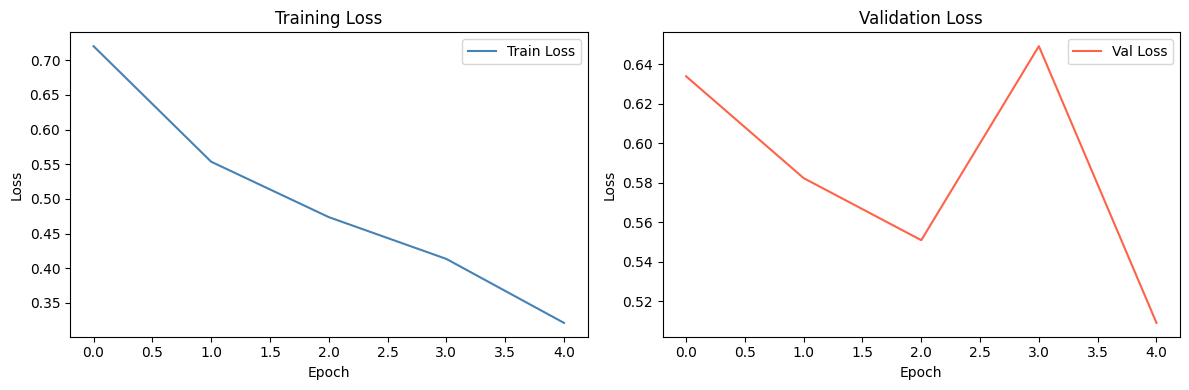

In [22]:
# 📊 Loss curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.title("Training Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.plot(train_history['loss'], label='Train Loss', color='steelblue')
plt.legend()

plt.subplot(1, 2, 2)
plt.title("Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.plot(train_history['val_loss'], label='Val Loss', color='tomato')
plt.legend()

plt.tight_layout()
plt.show()

#### ✅ Task 6 — Accuracy Curves

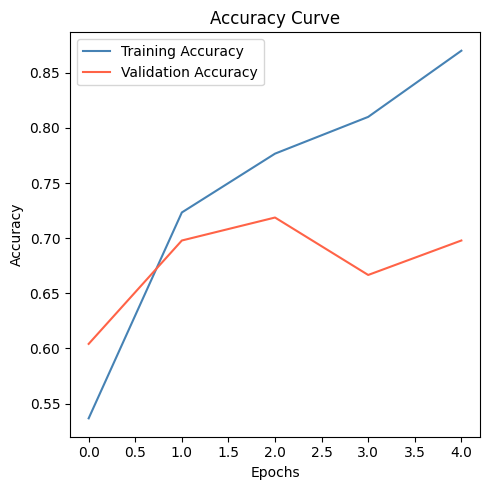

In [23]:
# ✅ Task 6 — Accuracy curves
plt.figure(figsize=(5, 5))
plt.plot(train_history['accuracy'],     label='Training Accuracy',   color='steelblue')
plt.plot(train_history['val_accuracy'], label='Validation Accuracy', color='tomato')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

### 1.6 🎯 Model Evaluation

I evaluate on the held-out test set — images the model has never seen. The `steps` argument ensures I evaluate on complete batches only (rounding down to avoid a partial batch at the end).

$$\text{Test Accuracy} = \frac{\text{Correct predictions}}{\text{Total test samples}}$$

In [24]:
# 🎯 Evaluate on test set
test_loss, test_accuracy = model.evaluate(
    test_generator,
    steps=test_generator.samples // test_generator.batch_size
)

print(f"\n{'─'*30}")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}  ({test_accuracy*100:.1f}%)")
print(f"{'─'*30}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6875 - loss: 0.7393

──────────────────────────────
Test Loss:     0.7393
Test Accuracy: 0.6875  (68.8%)
──────────────────────────────


### 1.7 🔍 Visualising Predictions

I define two helper functions:
- `plot_image_with_title()` — displays a single image with its true and predicted labels
- `test_model_on_image()` — pulls a batch from the test generator, runs inference, and calls the plot function

The threshold is $\hat{y} > 0.5$ → class 1, else class 0 — the standard sigmoid decision boundary.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def plot_image_with_title(image, model, true_label, predicted_label, class_names):
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    true_label_name = class_names[true_label]
    pred_label_name = class_names[predicted_label]
    color = 'green' if true_label == predicted_label else 'red'
    plt.title(f"True: {true_label_name}\nPred: {pred_label_name}", color=color, fontsize=14)
    plt.axis('off')
    plt.show()

def test_model_on_image(test_generator, model, index_to_plot=0):
    test_images, test_labels = next(test_generator)
    predictions = model.predict(test_images)
    # Sigmoid output → binary decision at threshold 0.5
    predicted_classes = (predictions > 0.5).astype(int).flatten()
    class_indices = test_generator.class_indices
    class_names = {v: k for k, v in class_indices.items()}
    image_to_plot    = test_images[index_to_plot]
    true_label       = test_labels[index_to_plot]
    predicted_label  = predicted_classes[index_to_plot]
    plot_image_with_title(
        image=image_to_plot, model=model,
        true_label=int(true_label), predicted_label=int(predicted_label),
        class_names=class_names
    )

#### ✅ Task 7 — Visualise a Prediction

I pick `index_to_plot=1` to display the second image from the next test batch. The title colour is green (correct) or red (incorrect).

> **Note:** Neural network predictions are probabilistic — a mismatch between true and predicted label is expected occasionally and does not indicate a broken model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


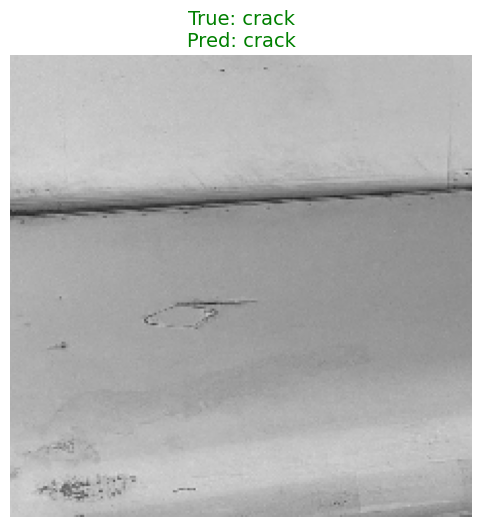

In [26]:
# ✅ Task 7 — Visualise prediction at index 1
index_to_plot = 1
test_model_on_image(test_generator, model, index_to_plot=index_to_plot)

---

## Part 2 — 🧠 Image Captioning with BLIP

Now I shift from classification to **image captioning**. Rather than outputting a class label, I generate a natural language sentence describing the image content.

I use **BLIP** (Bootstrapping Language-Image Pretraining) from Salesforce — a vision-language model that can caption, summarise, and answer visual questions. BLIP is built on a transformer architecture that fuses a Vision Transformer (ViT) image encoder with a BERT-style text decoder.

**Architecture at a glance:**

$$\text{Image} \xrightarrow{\text{ViT encoder}} \mathbf{v} \quad \xrightarrow{\text{cross-attention}} \quad \text{Decoder} \xrightarrow{\text{autoregressive}} \text{caption token by token}$$

I wrap BLIP inside a **custom Keras layer** (`BlipCaptionSummaryLayer`), allowing it to be called as part of a TensorFlow computation graph using `tf.py_function` — a bridge between PyTorch-based BLIP and TF's execution engine.

**Telecom analogy 📡:** BLIP's cross-attention is like a matched filter bank where the query is the visual signal and the keys/values are the learned text vocabulary. The decoder outputs the most likely sequence of tokens given the image — analogous to soft-decision Viterbi decoding of a sequence of symbols.

In [28]:
# 📥 Load libraries for Part 2
import torch
import tensorflow as tf
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration

### 2.1 🔢 Loading the BLIP Model

I load both the **processor** (handles image resizing and tokenisation) and the **model** (transformer weights) from Hugging Face Hub. Both are downloaded on first use and cached locally.

| Component | Role |
|---|---|
| `BlipProcessor` | Converts PIL images + text prompts → PyTorch tensors |
| `BlipForConditionalGeneration` | Generates text conditioned on the image tokens |

In [29]:
# 🔢 Load pretrained BLIP processor and model from Hugging Face
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model_blip = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
print("✅ BLIP model loaded successfully")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

✅ BLIP model loaded successfully


### Custom Keras Layer: `BlipCaptionSummaryLayer`

I implement a `tf.keras.layers.Layer` subclass that:
1. Accepts an image path (as a TF string tensor) and a task type
2. Loads and preprocesses the image with PIL
3. Generates caption or summary text via BLIP
4. Returns the result as a TF string tensor

The key design choice is `tf.py_function` — it wraps Python code (including PyTorch ops) inside TensorFlow's graph execution, handling the type conversions transparently.

**Subclassing pattern:**
- `__init__` → store processor and model as attributes
- `call` → define the forward pass (called when the layer is invoked)
- `process_image` → the actual Python logic, called via `tf.py_function`

In [31]:
class BlipCaptionSummaryLayer(tf.keras.layers.Layer):
    def __init__(self, processor, model, **kwargs):
        """
        Custom Keras layer wrapping BLIP for image captioning and summarization.

        Args:
            processor: BlipProcessor — preprocesses image+text into model inputs.
            model: BlipForConditionalGeneration — generates the caption/summary tokens.
        """
        super().__init__(**kwargs)
        self.processor = processor
        self.model = model

    def call(self, image_path, task):
        # tf.py_function bridges TensorFlow graph execution and Python/PyTorch code
        return tf.py_function(self.process_image, [image_path, task], tf.string)

    def process_image(self, image_path, task):
        """
        Core logic: load image → preprocess → generate text.

        Args:
            image_path: TF string tensor — path to the image file.
            task: TF string tensor — 'caption' or 'summary'.

        Returns:
            Generated caption or summary as a Python string.
        """
        try:
            # Decode TF tensors → Python strings
            image_path_str = image_path.numpy().decode("utf-8")
            task_str = task.numpy().decode("utf-8")

            # Open and convert image to RGB (handles grayscale or RGBA inputs)
            img = Image.open(image_path_str).convert("RGB")

            # Set prompt based on task — prompt conditions the decoder's generation
            if task_str == "caption":
                prompt = "This is a picture of"
            else:  # summary
                prompt = "This is a detailed photo showing"

            # Prepare inputs: image tensor + tokenised prompt
            inputs = self.processor(images=img, text=prompt, return_tensors="pt")

            # Generate output tokens (autoregressive decoding)
            output = self.model.generate(**inputs)

            # Decode token IDs → human-readable string
            result = self.processor.decode(output[0], skip_special_tokens=True)
            return result

        except Exception as e:
            print(f"Error during image processing: {e}")
            return "Error processing image"

### 2.2 📤 Generating Captions and Summaries

I now demonstrate the full pipeline on a test image. The `generate_text` helper instantiates the custom layer and invokes it with the image path and task type.

**Caption vs. Summary — what's the difference?**

| Task | Prompt prefix | Typical output |
|---|---|---|
| `caption` | "This is a picture of" | Short, factual description |
| `summary` | "This is a detailed photo showing" | Longer, more descriptive output |

In [32]:
# Demo: caption + summary for a dent image
image_path_demo = tf.constant("aircraft_damage_dataset_v1/test/dent/144_10_JPG_jpg.rf.4d008cc33e217c1606b76585469d626b.jpg")

blip_layer_demo = BlipCaptionSummaryLayer(processor, model_blip)

caption_demo = blip_layer_demo(image_path_demo, tf.constant("caption"))
print("Caption:", caption_demo.numpy().decode("utf-8"))

summary_demo = blip_layer_demo(image_path_demo, tf.constant("summary"))
print("Summary:", summary_demo.numpy().decode("utf-8"))

Caption: this is a picture of a plane
Summary: this is a detailed photo showing the engine of a boeing 747


#### ✅ Task 8 — Helper Function `generate_text`

I implement a clean helper function that encapsulates the layer instantiation and invocation. It accepts `image_path` and `task` as TF constant tensors and returns the generated text tensor.

In [36]:
# ✅ Task 8 — generate_text helper function
def generate_text(image_path, task):
    """
    Generate a caption or summary for an image using the BLIP model.

    Args:
        image_path (tf.Tensor): String tensor — path to the image file.
        task (tf.Tensor): String tensor — 'caption' or 'summary'.

    Returns:
        tf.Tensor: String tensor containing the generated text.
    """
    blip_layer = BlipCaptionSummaryLayer(processor, model_blip)
    return blip_layer(image_path, task)

#### ✅ Task 9 — Generate Caption

I load the target test image, display it, and generate a caption using `generate_text` with `task='caption'`.

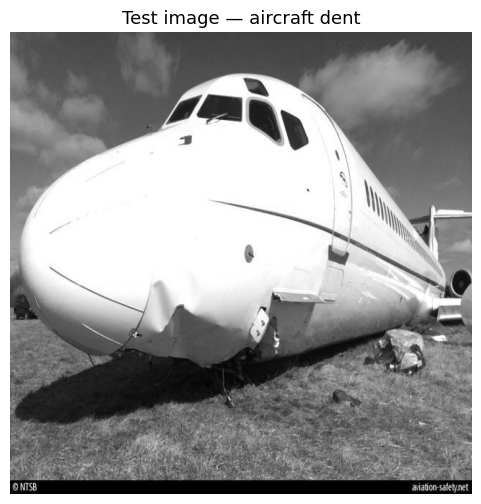

In [37]:
# Display the target image
image_url = "aircraft_damage_dataset_v1/test/dent/149_22_JPG_jpg.rf.4899cbb6f4aad9588fa3811bb886c34d.jpg"
img = plt.imread(image_url)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title("Test image — aircraft dent", fontsize=13)
plt.show()

In [38]:
# ✅ Task 9 — Generate caption
image_path = tf.constant("aircraft_damage_dataset_v1/test/dent/149_22_JPG_jpg.rf.4899cbb6f4aad9588fa3811bb886c34d.jpg")

caption = generate_text(image_path, tf.constant("caption"))
print("Caption:", caption.numpy().decode("utf-8"))

Caption: this is a picture of a plane that was sitting on the ground in a field


#### ✅ Task 10 — Generate Summary

In [39]:
# ✅ Task 10 — Generate summary
image_path = tf.constant("aircraft_damage_dataset_v1/test/dent/149_22_JPG_jpg.rf.4899cbb6f4aad9588fa3811bb886c34d.jpg")

summary = generate_text(image_path, tf.constant("summary"))
print("Summary:", summary.numpy().decode("utf-8"))

Summary: this is a detailed photo showing the damage to the fuselage of the aircraft


---

## 📊 Summary

| # | Task | Technique | Key decision |
|---|---|---|---|
| 1 | Valid generator | `flow_from_directory` | `shuffle=False` — consistent eval order |
| 2 | Test generator | `flow_from_directory` | `shuffle=False` — labels must match predictions |
| 3 | Load VGG16 | `weights='imagenet'`, `include_top=False` | Reuse 13 Conv blocks, discard ImageNet head |
| 4 | Compile model | `Adam(lr=1e-4)`, `binary_crossentropy` | Low LR to avoid disrupting frozen features |
| 5 | Train model | `model.fit(train_generator, epochs=5)` | 5 epochs sufficient for feature extraction head |
| 6 | Accuracy curves | `plt.plot(train/val accuracy)` | Diagnose overfitting / underfitting |
| 7 | Visualise prediction | `test_model_on_image()` | Sigmoid threshold $\hat{y} > 0.5$ → class 1 |
| 8 | `generate_text()` helper | `BlipCaptionSummaryLayer` | `tf.py_function` bridges TF ↔ PyTorch |
| 9 | Image caption | BLIP `"caption"` task | Prompt: "This is a picture of" |
| 10 | Image summary | BLIP `"summary"` task | Prompt: "This is a detailed photo showing" |

### Key takeaways

- **Transfer learning** via frozen VGG16 lets me build a high-accuracy binary classifier with just 5 epochs and a small custom head — no need to train millions of weights from scratch.
- **Binary cross-entropy + sigmoid** is the correct pair for 2-class problems; use categorical cross-entropy + softmax for $N > 2$ classes.
- **Custom Keras layers** extend TensorFlow's graph with arbitrary Python logic via `tf.py_function`, enabling multi-framework pipelines (e.g., Hugging Face PyTorch models inside a Keras model).
- **BLIP** is a practical example of a **multimodal model** — it fuses visual and linguistic representations in a shared transformer attention space.
- **Dropout(0.3)** regularises the Dense head, reducing overfitting on a small dataset by preventing co-adaptation of neurons.

---

## 🧪 Sandbox — Experiments to Try

These cells are for exploration. They won't break the main pipeline.

In [ ]:
# 🧪 Experiment 1 — Unfreeze the last VGG16 block for fine-tuning
# After feature extraction converges, unfreeze block5 for a few more epochs

# for layer in base_model.layers:
#     if 'block5' in layer.name:
#         layer.trainable = True
#         print(f"  Unfrozen: {layer.name}")

# # Re-compile with a very low LR to avoid destroying pretrained features
# model.compile(
#     optimizer=Adam(learning_rate=1e-5),
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )
# history_ft = model.fit(train_generator, epochs=3, validation_data=valid_generator)

print("Uncomment the block above to try fine-tuning on VGG16 block5")

In [ ]:
# 🧪 Experiment 2 — Add data augmentation to the training generator
# Augmentation helps when the training set is small — more variation = better generalisation

# train_datagen_aug = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=15,        # random rotation ±15°
#     width_shift_range=0.1,    # horizontal shift
#     height_shift_range=0.1,   # vertical shift
#     horizontal_flip=True,     # mirror flip
#     zoom_range=0.1            # random zoom
# )
# train_generator_aug = train_datagen_aug.flow_from_directory(
#     train_dir, target_size=(224, 224), batch_size=32, class_mode='binary', seed=42
# )

print("Uncomment the block above to try augmented training")

In [ ]:
# 🧪 Experiment 3 — Test BLIP on a custom image URL
# Replace the path below with any image from the dataset or your own file

# custom_path = tf.constant("aircraft_damage_dataset_v1/test/crack/<your_image_filename>.jpg")
# result = generate_text(custom_path, tf.constant("caption"))
# print("Caption:", result.numpy().decode("utf-8"))

print("Uncomment the block above to caption any image in the dataset")

In [ ]:
# 🧪 Experiment 4 — Confusion matrix on the full test set
# A confusion matrix reveals asymmetric error rates (false dents vs. false cracks)

# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import numpy as np

# test_generator.reset()
# preds = model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size)
# pred_classes = (preds > 0.5).astype(int).flatten()
# true_classes = test_generator.classes[:len(pred_classes)]

# cm = confusion_matrix(true_classes, pred_classes)
# disp = ConfusionMatrixDisplay(cm, display_labels=['crack', 'dent'])
# disp.plot(colorbar=False)
# plt.title('Confusion Matrix — Test Set')
# plt.show()

print("Uncomment the block above to plot the confusion matrix")